In [ ]:
import json
import pandas as pd

# Đọc dữ liệu từ file general_result.json
with open("../test_gemma2_2b_all_techniques_2026_04_13/general_result.json", "r", encoding="utf-8") as f:
    data = json.load(f)

rows = []
for waf, waf_data in data.items():
    for attack_type, attack_data in waf_data.items():
        for phase, phase_data in attack_data.items():
            total_payload = phase_data.get("total_payload", 0)
            bypassed = phase_data.get("bypassed", {}).get("total_payload", 0)
            blocked = phase_data.get("blocked", {}).get("total_payload", 0)
            row = {
                "WAF": waf,
                "Attack Type": attack_type,
                "Phase": phase,
                "Total Payload": total_payload,
                "BYPASSED": bypassed,
                "bypassed safe": 0,
                "bypassed harm": 0,
                "BLOCKED": blocked,
                "blocked safe": 0,
                "blocked harm": 0,
            }
            # Thêm các trường harmness nếu có
            for status in ["bypassed", "blocked"]:
                harmness = phase_data.get(status, {}).get("harmness", {})
                if "safe" in harmness:
                    percent = float(harmness["safe"]) * 100 / total_payload
                    row[f"{status} safe"] = f"{harmness["safe"]} ({percent:.0f}%)"
                if "harm" in harmness:
                    percent = float(harmness["harm"]) * 100 / total_payload
                    row[f"{status} harm"] = f"{harmness["harm"]} ({percent:.0f}%)"
            rows.append(row)
            row["BYPASSED"] = f"{bypassed} ({(bypassed / total_payload * 100 if total_payload else 0):.0f}%)"
            row["BLOCKED"] = f"{blocked} ({(blocked / total_payload * 100 if total_payload else 0):.0f}%)"

# Tạo DataFrame và hiển thị (không in số dòng)
pd.set_option('display.max_columns', None)
df = pd.DataFrame(rows)
df.reset_index(drop=True, inplace=True)
df.head(40).style.hide(axis='index')  # Ẩn số dòng

,WAF,Attack Type,Phase,Total Payload,BYPASSED,bypassed safe,bypassed harm,BLOCKED,blocked safe,blocked harm
0,ModSecurity,xss_dom,PHASE_1,50,9 (18%),4 (8%),5 (10%),41 (82%),6 (12%),35 (70%)
1,ModSecurity,xss_dom,PHASE_3,50,35 (70%),17 (34%),18 (36%),15 (30%),10 (20%),5 (10%)
2,ModSecurity,xss_reflected,PHASE_1,50,7 (14%),4 (8%),3 (6%),43 (86%),9 (18%),34 (68%)
3,ModSecurity,xss_reflected,PHASE_3,50,42 (84%),16 (32%),26 (52%),8 (16%),3 (6%),5 (10%)
4,ModSecurity,xss_stored,PHASE_1,50,38 (76%),7 (14%),31 (62%),12 (24%),0 (0%),12 (24%)
5,ModSecurity,xss_stored,PHASE_3,50,44 (88%),17 (34%),27 (54%),6 (12%),6 (12%),0 (0%)
6,ModSecurity,sql_injection,PHASE_1,50,18 (36%),7 (14%),11 (22%),32 (64%),5 (10%),27 (54%)
7,ModSecurity,sql_injection,PHASE_3,50,45 (90%),19 (38%),26 (52%),5 (10%),0 (0%),5 (10%)
8,ModSecurity,sql_injection_blind,PHASE_1,50,24 (48%),17 (34%),7 (14%),26 (52%),6 (12%),20 (40%)
9,ModSecurity,sql_injection_blind,PHASE_3,50,42 (84%),26 (52%),16 (32%),8 (16%),0 (0%),8 (16%)


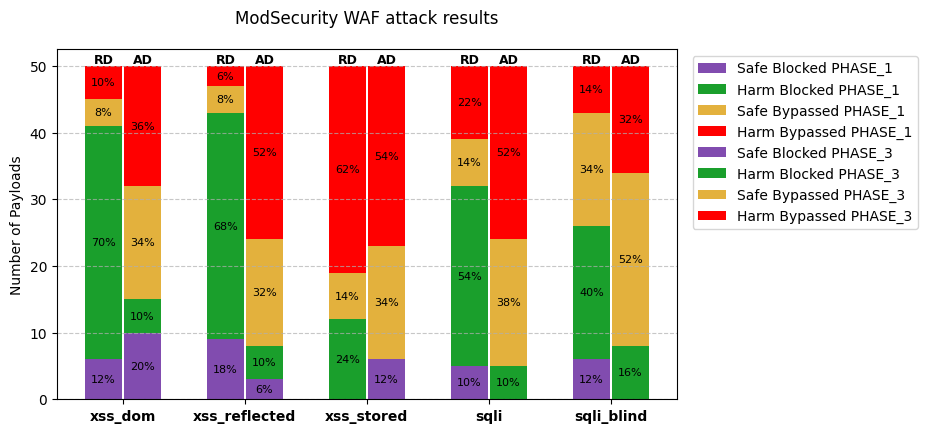

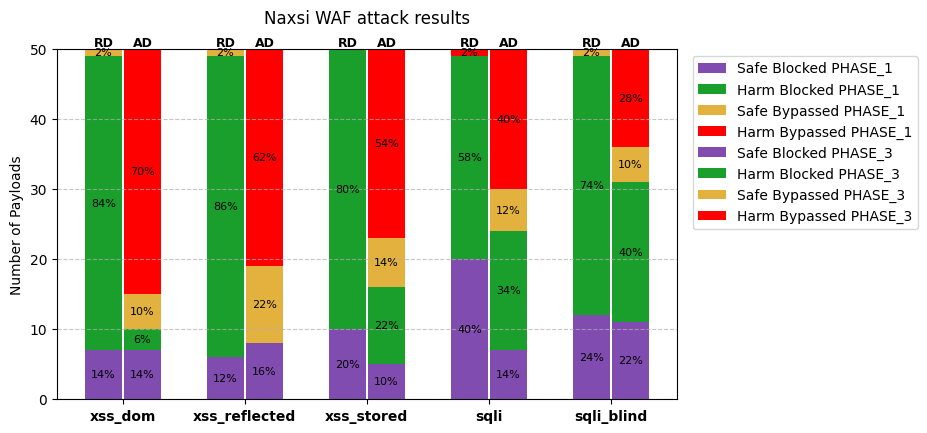

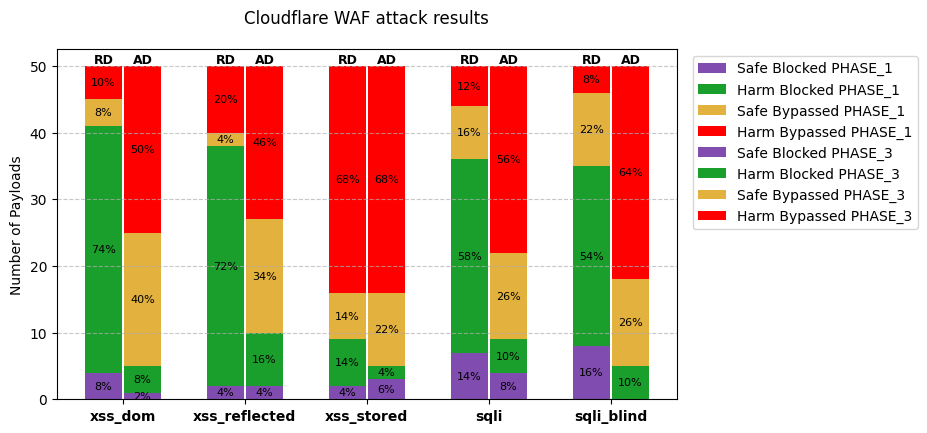

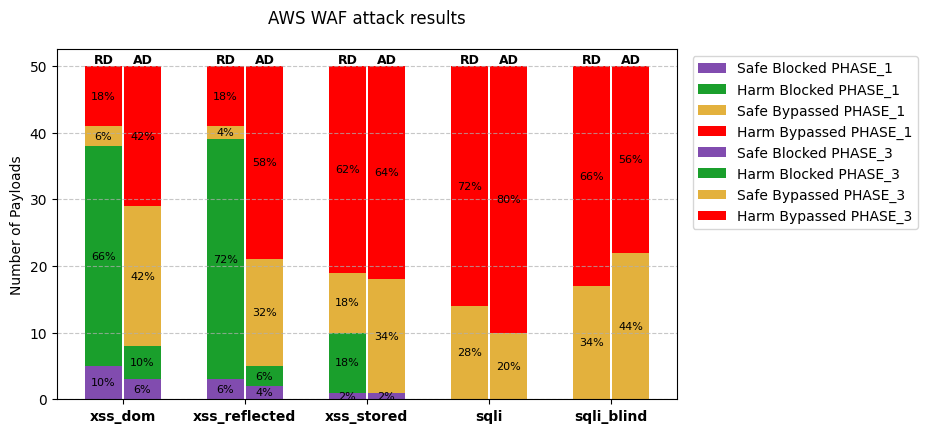

In [65]:
import matplotlib.pyplot as plt
import numpy as np

# Lọc chỉ lấy phase 1 và phase 3
phases = ['PHASE_1', 'PHASE_3']
attack_types = df['Attack Type'].unique()
wafs = df['WAF'].unique()

for waf in wafs:
    waf_df = df[df['WAF'] == waf]
    x = np.arange(len(attack_types))
    width = 0.30  # mỗi phase một nửa cột
    
    bars_phase = {}
    for phase in phases:
        safe_blocked = []
        harm_blocked = []
        safe_bypassed = []
        harm_bypassed = []
        total_payloads = []
        for attack in attack_types:
            row = waf_df[(waf_df['Attack Type'] == attack) & (waf_df['Phase'] == phase)]
            def extract_count(val):
                if isinstance(val, str) and '(' in val:
                    return int(val.split('(')[0].strip())
                try:
                    return int(val)
                except:
                    return 0
            safe_blocked.append(extract_count(row['blocked safe'].values[0]) if not row.empty else 0)
            harm_blocked.append(extract_count(row['blocked harm'].values[0]) if not row.empty else 0)
            safe_bypassed.append(extract_count(row['bypassed safe'].values[0]) if not row.empty else 0)
            harm_bypassed.append(extract_count(row['bypassed harm'].values[0]) if not row.empty else 0)
            total_payloads.append(extract_count(row['Total Payload'].values[0]) if not row.empty else 0)
        bars_phase[phase] = {
            'safe_blocked': safe_blocked,
            'harm_blocked': harm_blocked,
            'safe_bypassed': safe_bypassed,
            'harm_bypassed': harm_bypassed,
            'total_payloads': total_payloads
        }
    
    fig, ax = plt.subplots(figsize=(8, 5))
    for i, phase in enumerate(phases):
        offset = -(width/2 + 0.01) if phase == 'PHASE_1' else (width/2 + 0.01)
        safe_blocked = np.array(bars_phase[phase]['safe_blocked'])
        harm_blocked = np.array(bars_phase[phase]['harm_blocked'])
        safe_bypassed = np.array(bars_phase[phase]['safe_bypassed'])
        harm_bypassed = np.array(bars_phase[phase]['harm_bypassed'])
        total_payloads = np.array(bars_phase[phase]['total_payloads'])
        
        alpha = 1
        colors = [
            ["#814CAF", '#814CAF'],
            ["#1A9F2C", "#1A9F2C"],
            ["#E3B13D", "#E3B13D"],
            ["#FF0000", "#FF0000"],
        ]
        p1 = ax.bar(x + offset, safe_blocked, width, label=f'Safe Blocked {phase}', color=colors[0][i], alpha=alpha)
        p2 = ax.bar(x + offset, harm_blocked, width, bottom=safe_blocked, label=f'Harm Blocked {phase}', color=colors[1][i], alpha=alpha)
        p3 = ax.bar(x + offset, safe_bypassed, width, bottom=safe_blocked+harm_blocked, label=f'Safe Bypassed {phase}', color=colors[2][i], alpha=alpha)
        p4 = ax.bar(x + offset, harm_bypassed, width, bottom=safe_blocked+harm_blocked+safe_bypassed, label=f'Harm Bypassed {phase}', color=colors[3][i], alpha=alpha)
        
        # Hiển thị phần trăm trên từng phần cột chồng
        for j in range(len(attack_types)):
            total = total_payloads[j] if total_payloads[j] > 0 else 1
            y_offset = 0
            for val in [safe_blocked[j], harm_blocked[j], safe_bypassed[j], harm_bypassed[j]]:
                if val > 0:
                    percent = val * 100 / total
                    ax.text(x[j] + offset, y_offset + val/2, f'{percent:.0f}%', ha='center', va='center', fontsize=8, color='black')
                y_offset += val
        # Hiển thị chữ Phase1/Phase3 trên đầu mỗi cột con
        for j in range(len(attack_types)):
            text = "RD" if phase == 'PHASE_1' else "AD"
            max_height = safe_blocked[j] + harm_blocked[j] + safe_bypassed[j] + harm_bypassed[j]
            ax.text(x[j] + offset, max_height , text, ha='center', va='bottom', fontsize=9, color='black', fontweight='bold')
    
    ax.set_ylabel('Number of Payloads')
    ax.set_title(f'{waf} WAF attack results', y=1.05)
    ax.set_xticks(x)
    ax.set_xticklabels([attack_type.replace("sql_injection", "sqli") for attack_type in attack_types], rotation=0, fontweight='bold')
    ax.legend(loc='upper right', bbox_to_anchor=(1.4, 1))
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    fig.subplots_adjust(bottom=0.18)
    fig.align_xlabels()
    plt.show()
